# 03. Analysis RQ1: Trend & Geopolitics (趋势与地缘政治)

**Research Question:** How have movie genres and production powerhouses shifted over the last 20 years?
**核心问题:** 过去20年间，电影类型的流行趋势和制片国家的版图发生了怎样的地缘与时间转移？

**Steps:**
1. Load Data & Preprocessing (加载数据与预处理)
2. Genre Evolution Analysis (电影类型演变分析)
3. Production Country Analysis (制片国家分析)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set(style="whitegrid")

# Load Processed Data
PROCESSED_DATA_PATH = '../data/processed/clean_tmdb_movies.csv'
df = pd.read_csv(PROCESSED_DATA_PATH)

# Parse list columns (they load as strings from CSV)
list_cols = ['genres', 'production_countries']
for col in list_cols:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

print(f"Data Loaded: {df.shape}")
display(df.head(2))

Data Loaded: (5646, 28)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,tagline,genres,production_companies,production_countries,spoken_languages,keywords,release_year,release_month,release_quarter,roi
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Your mind is the scene of the crime.,"[Action, Science Fiction, Adventure]","['Legendary Pictures', 'Syncopy', 'Warner Bros...","[United Kingdom, United States of America]","['English', 'French', 'Japanese', 'Swahili']","rescue, mission, dream, airplane, paris, franc...",2010.0,7.0,3.0,4.159580
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Mankind was born on Earth. It was never meant ...,"[Adventure, Drama, Science Fiction]","['Legendary Pictures', 'Syncopy', 'Lynda Obst ...","[United Kingdom, United States of America]",['English'],"rescue, future, spacecraft, race against time,...",2014.0,11.0,4.0,3.252904


## 2. Genre Evolution (电影类型演变)
We will analyze how the popularity of different genres has changed over the years (2004-2023).

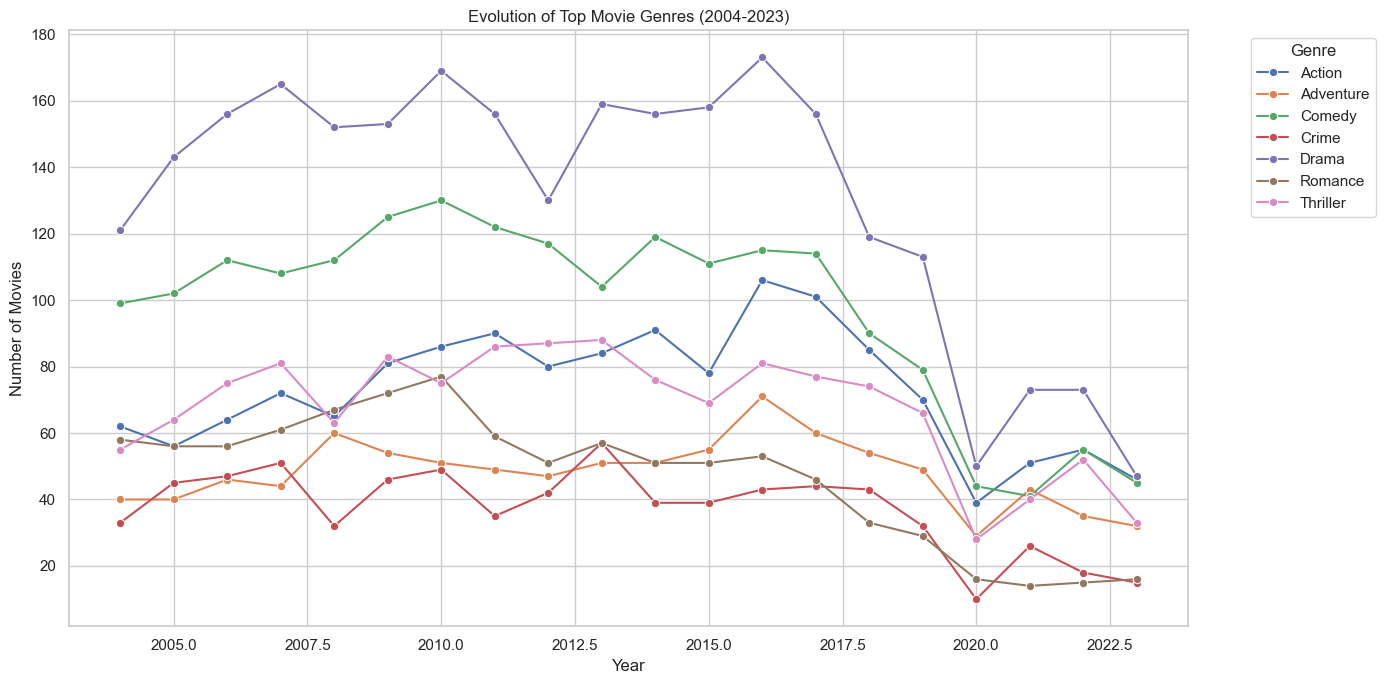

In [ ]:
# Explode genres so each genre gets its own row
df_genres = df.explode('genres')

# Count movies per genre per year
genre_trends = df_genres.groupby(['release_year', 'genres']).size().reset_index(name='count')

# Filter for top 7 genres for cleaner visualization
top_genres = df_genres['genres'].value_counts().head(7).index.tolist()
genre_trends_top = genre_trends[genre_trends['genres'].isin(top_genres)]

# --- 美化代码开始 ---
# 设置整体风格
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)
sns.set_palette(["#e63946", "#f4a261", "#2a9d8f", "#264653", "#8ab17d", "#e9c46a", "#e76f51"])

fig, ax = plt.subplots(figsize=(15, 8))

# 绘制平滑的带阴影折线图，更有高级感
sns.lineplot(
    data=genre_trends_top, 
    x='release_year', 
    y='count', 
    hue='genres', 
    marker='o',
    markersize=8,
    linewidth=2.5,
    ax=ax
)

# 移除上边和右边的边框
sns.despine()

# 标题和坐标轴美化
plt.title('Evolution of Top Movie Genres (2004-2023)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Release Year', fontsize=16, fontweight='bold')
plt.ylabel('Number of Movies Produced', fontsize=16, fontweight='bold')

# 确保X轴显示整数年份
ax.set_xticks(range(int(genre_trends_top['release_year'].min()), int(genre_trends_top['release_year'].max()) + 1, 2))

# 优化图例
plt.legend(
    title='Movie Genre', 
    title_fontsize='14', 
    fontsize='13',
    bbox_to_anchor=(1.02, 1), 
    loc='upper left',
    frameon=False # 去除图例边框
)

# 添加背后的虚线网格以提升可读性
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../reports/figures/rq1_genre_evolution_beautiful.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## 3. Production Powerhouses (制片国家版图)
Which countries have been dominating the movie industry? Has there been a shift?

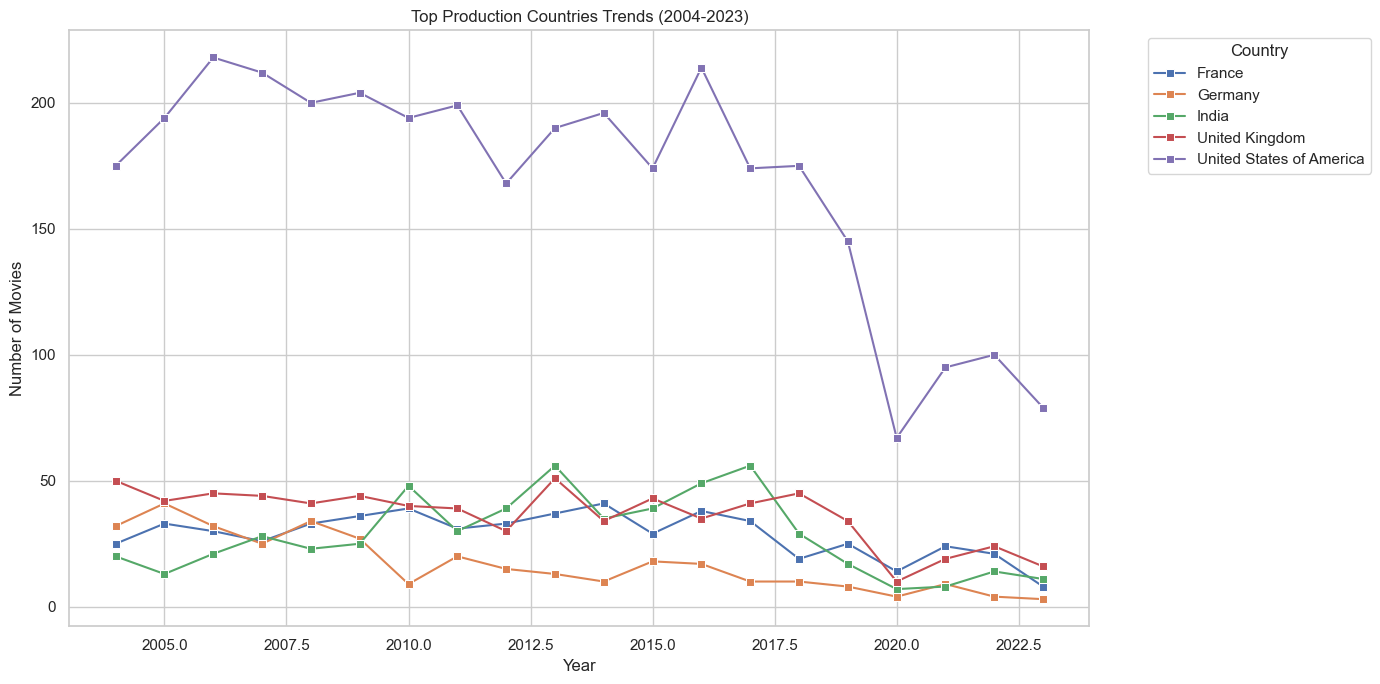

In [ ]:
# Explode countries
df_countries = df.explode('production_countries')

# Count movies per country per year
country_trends = df_countries.groupby(['release_year', 'production_countries']).size().reset_index(name='count')

# Filter for top 5 countries
top_countries = df_countries['production_countries'].value_counts().head(5).index.tolist()
country_trends_top = country_trends[country_trends['production_countries'].isin(top_countries)]


# --- 美化代码开始 ---
# 使用不同的调色板以区分主题
sns.set_palette(["#003f5c", "#bc5090", "#ffa600", "#58508d", "#ff6361"])

fig, ax = plt.subplots(figsize=(15, 8))

# 绘制折线图
sns.lineplot(
    data=country_trends_top, 
    x='release_year', 
    y='count', 
    hue='production_countries', 
    marker='s', # 用方块作为标记点
    markersize=8,
    linewidth=2.5,
    ax=ax
)

# 移除边框
sns.despine()

# 由于美国的数量绝对碾压，导致其他国家挤在底部，我们建议开启对数坐标轴，但这可能会误导读者。
# 更好的方式是保持线性，但美化外观，并在报告中解释 "US Hegemony" (美国霸权)。
plt.title('Global Production Powerhouses (2004-2023)', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Release Year', fontsize=16, fontweight='bold')
plt.ylabel('Number of Movies Produced', fontsize=16, fontweight='bold')

# X 轴刻度
ax.set_xticks(range(int(country_trends_top['release_year'].min()), int(country_trends_top['release_year'].max()) + 1, 2))

# 优化图例
plt.legend(
    title='Production Country', 
    title_fontsize='14', 
    fontsize='13',
    bbox_to_anchor=(1.02, 1), 
    loc='upper left',
    frameon=False
)

ax.grid(True, linestyle='--', alpha=0.7)

# 给美国的最高点加一个高光标注注释 (让图表更有故事性)
us_data = country_trends_top[country_trends_top['production_countries'] == 'United States of America']
max_us_year = us_data.loc[us_data['count'].idxmax(), 'release_year']
max_us_count = us_data['count'].max()

ax.annotate('US Post-Covid Peak', 
            xy=(max_us_year, max_us_count),
            xytext=(max_us_year-4, max_us_count - (max_us_count*0.1)),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=12, fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9))

plt.tight_layout()
plt.savefig('../reports/figures/rq1_country_trends_beautiful.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()